In [1]:
from utils.plotting import *
from utils.auger.fd import NightSkyBackground

22:36:20 (   +2.1s) [INFO   ] -- import logging
22:36:20 (  +147ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
22:36:20 (    +2ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
22:36:20 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
22:36:20 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
22:36:20 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
22:36:20 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
22:36:20 (  +472ms) [INFO   ] -- import matplotlib.pyplot as plt
22:36:21 (   +1.1s) [INFO   ] -- import seaborn as so
22:36:21 (    +3ms) [INFO   ] -- import numpy as np
22:36:21 (   +12ms) [INFO   ] -- import uncertainties
22:36:21 (    +1ms) [INFO   ] -- import pandas as pd
22:36:21 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
22:36:21 (    +2ms) [INFO   ] -- import binaries.tools as t

In [2]:
# data = {}

# for site in [
#     'LosLeones',
#     'LosMorados',
#     'LomaAmarilla',
#     'Coihueco',
#     'Heat'
#     ]:

#     for tel in range(1, 7 if site != 'Heat' else 4):
#         test = NightSkyBackground.CameraNSB(site, tel)
#         data[f"{site}{tel}"] = len(test.df)

In [3]:
CO4 = NightSkyBackground.CameraNSB("Coihueco", 4)

loading /cr/tempdata01/filip/nsb_data/Coihueco4/nsb_2014-05-01_to_2014-06-01.pkl...
180 files (15.0 yrs) loaded for Coihueco #4


In [4]:
pixel210 = CO4.get_pixel(210)

9 outliers removed for pixel = 210


22:37:11 (  +49.7s) [DEBUG  ] -- font size set to 9.5
22:37:11 (    +2ms) [DEBUG  ] -- label size set to 13.0
22:37:11 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
22:37:11 (    +1ms) [DEBUG  ] -- markersize set to 2.0
22:37:11 (    +1ms) [DEBUG  ] -- usetex set to False


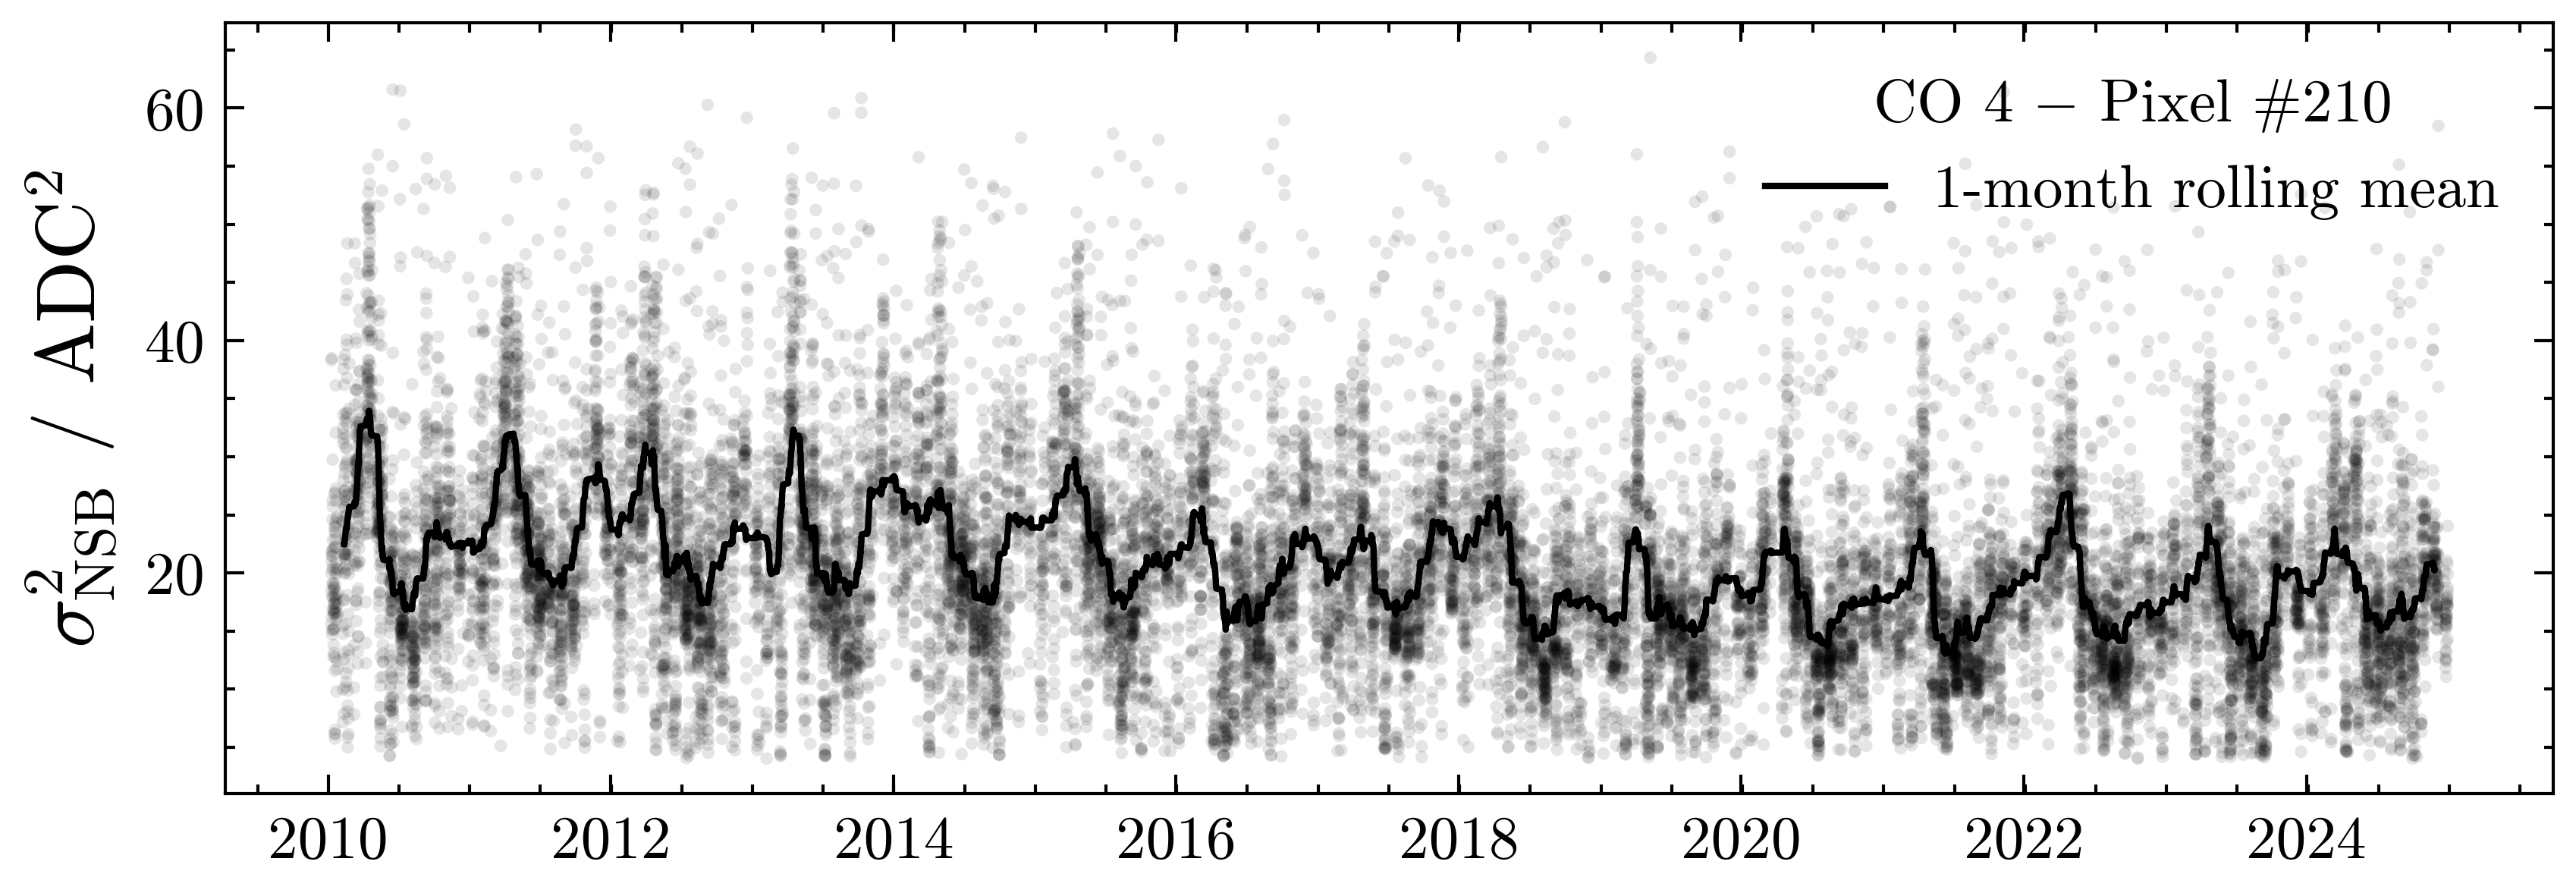

In [5]:
set_plt_style("slim")

pixel210.show(show_mean=True)

In [8]:
from utils.binaries import *

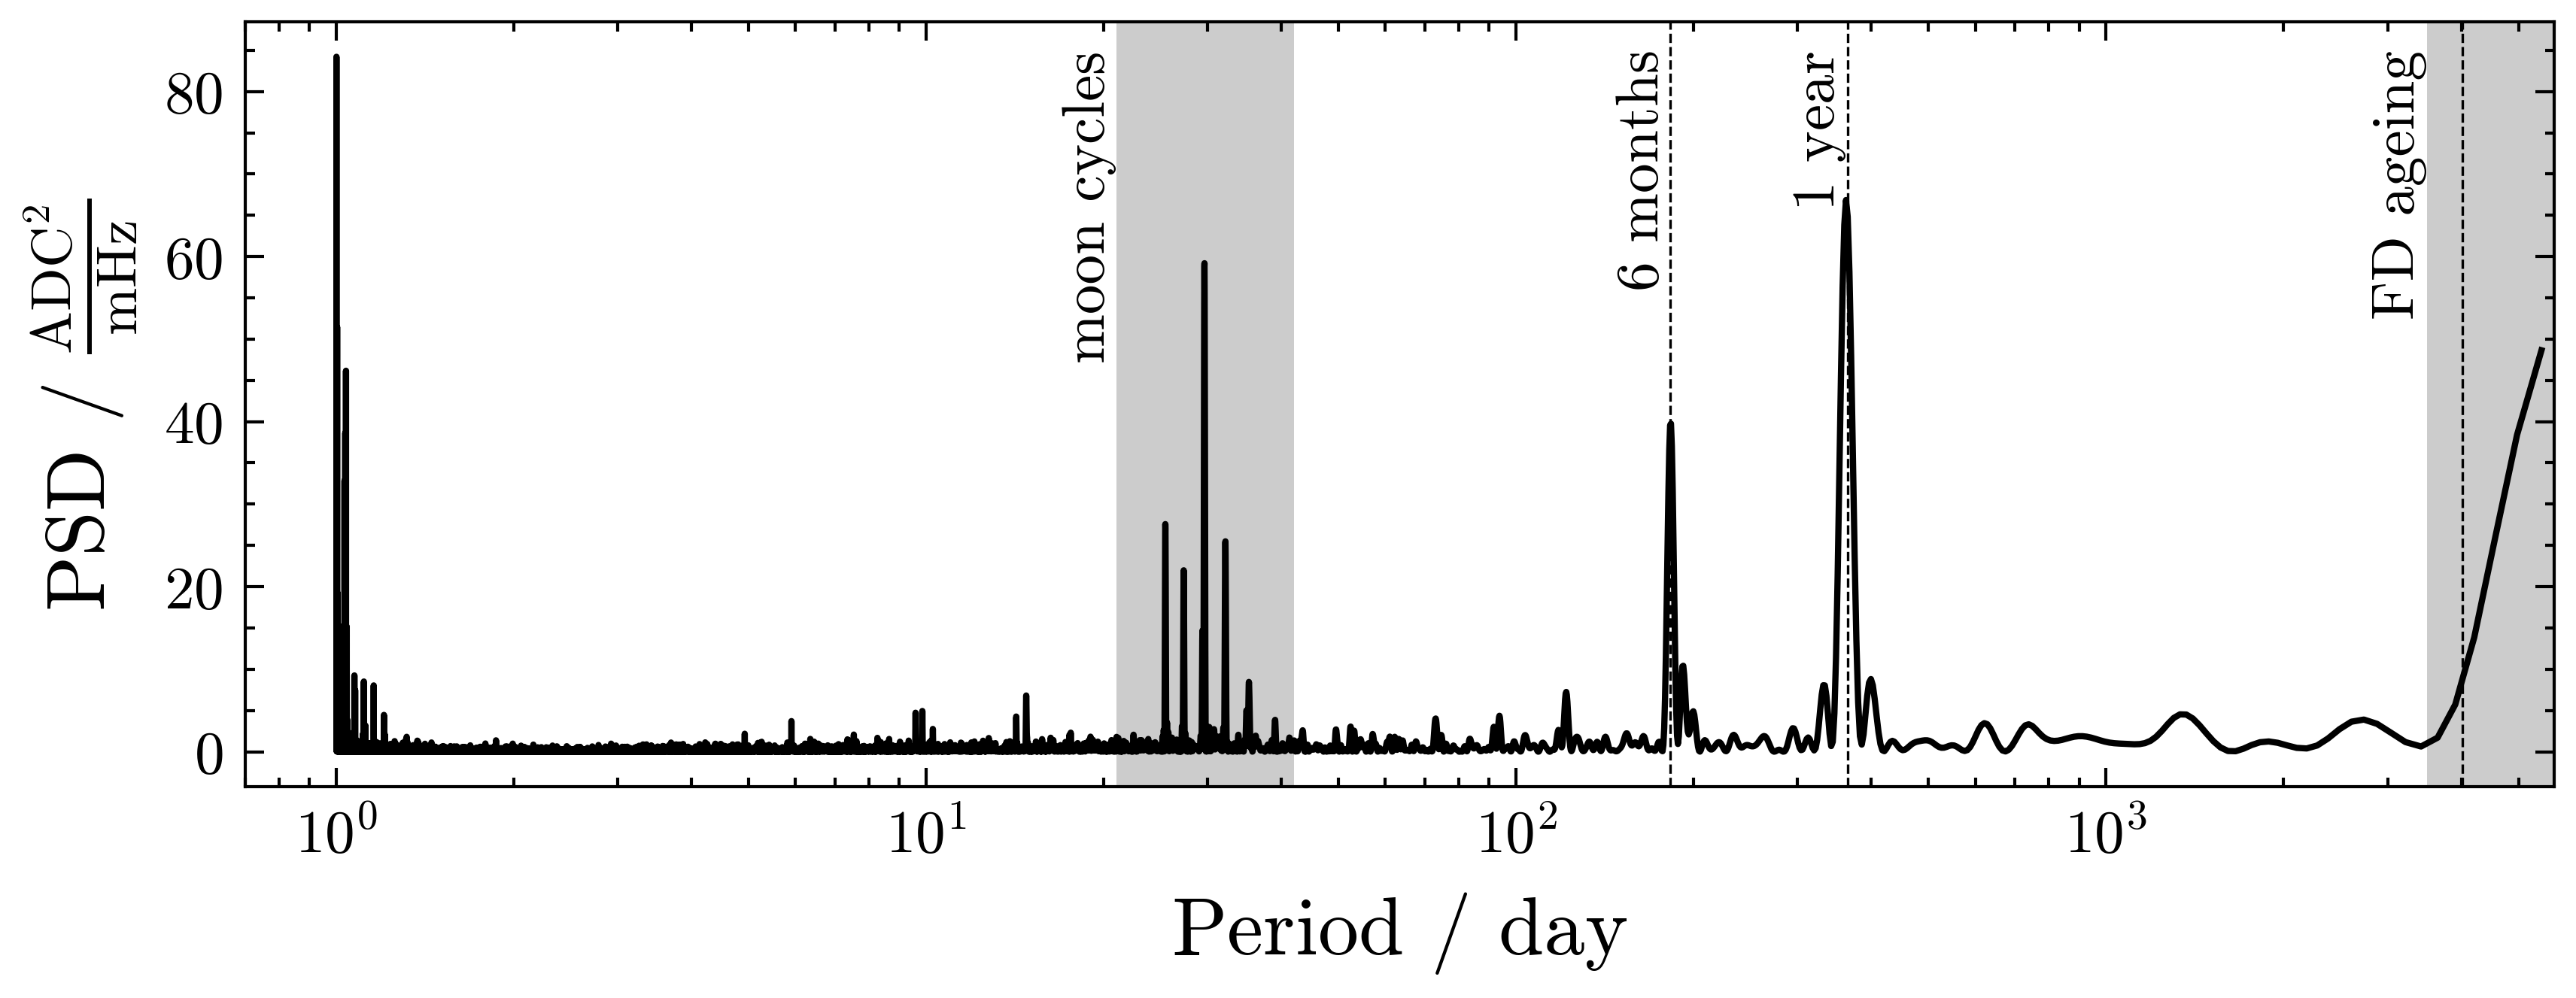

In [ ]:
periodogramm = pixel210.periodogram(show=False)

# x, y = periodogramm.power_spectral_density()
freq, power = periodogramm.autopower(
        minimum_frequency = 1/np.max(periodogramm.t),
        maximum_frequency = 1,
        samples_per_peak = 10,
        normalization = "psd"
)

mask = np.argsort(period := 1/freq)
x, y = period[mask], power[mask] / 1e3

plt.plot(x, y, marker='none')
plt.axvline(365.25, c='k', ls='--', lw=0.4)
plt.axvline(365.25/2, c='k', ls='--', lw=0.4)
plt.axvspan(21, 42, ec='none', fc='k', alpha=0.2)

xmin, xmax = plt.gca().get_xlim()
plt.axvspan(3500, xmax, ec='none', fc='k', alpha=0.2)

ax = plt.gca()
ax.set_xlim(0.7, xmax)

ax.text(
    21, 85,
    "moon cycles",
    rotation=90,
    ha='right', va='top'
)

ax.text(
    365.25/2, 85,
    r"$6$ months",
    rotation=90,
    ha='right', va='top'
)

ax.text(
    365.25, 85,
    r"$1$ year",
    rotation=90,
    ha='right', va='top'
)

ax.text(
    3500, 85,
    r"FD ageing",
    rotation=90,
    ha='right', va='top'
)

ax.set_xlabel('Period / $\mathrm{day}$')
ax.set_ylabel(r"PSD / $\frac{\mathrm{ADC}^2}{\mathrm{mHz}}$")
ax.set_xscale("log") 

In [ ]:
print(xmin)